# 🔍 Customer Churn Prediction 

## 1. Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

print("All libraries loaded successfully ✅")


All libraries loaded successfully ✅


## 2. Load & Combine Datasets

In [ ]:
df_train_raw = pd.read_csv("D:\Churn\Dataset\customer_churn_dataset-training-master.csv.zip")
df_test_raw  = pd.read_csv("D:\Churn\Dataset\customer_churn_dataset-testing-master.csv.zip")

print(f"Training CSV shape:  {df_train_raw.shape}")
print(f"Testing CSV  shape:  {df_test_raw.shape}")

# Show the distribution mismatch problem
print("\n--- WHY WE COMBINE: Label Distribution Mismatch ---")
print(f"Training CSV  Churn distribution: {df_train_raw['Churn'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Testing  CSV  Churn distribution: {df_test_raw['Churn'].value_counts(normalize=True).round(3).to_dict()}")
print("These distributions are very different, making direct cross-dataset evaluation misleading!")

# Combine both into one clean dataset
df = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")
df.head()


Training CSV shape:  (440833, 12)
Testing CSV  shape:  (64374, 12)

--- WHY WE COMBINE: Label Distribution Mismatch ---
Training CSV  Churn distribution: {1.0: 0.567, 0.0: 0.433}
Testing  CSV  Churn distribution: {0: 0.526, 1: 0.474}
These distributions are very different, making direct cross-dataset evaluation misleading!

Combined dataset shape: (505207, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB
None

Missing values per column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequ

In [21]:
# ⚠️ KEY INSIGHT: CustomerID is a data leakage source!
print("Correlation of ALL features with Churn:")

df_tmp = df.copy()
df_tmp['Gender']            = df_tmp['Gender'].map({'Male': 0, 'Female': 1})
df_tmp['Subscription Type'] = df_tmp['Subscription Type'].map({'Basic': 0, 'Standard': 1, 'Premium': 2})
df_tmp['Contract Length']   = df_tmp['Contract Length'].map({'Monthly': 0, 'Quarterly': 1, 'Annual': 2})
df_tmp = df_tmp.dropna()

print(df_tmp.corr(numeric_only=True)['Churn'].sort_values(ascending=False).to_string())
print("\n⚠️  CustomerID has high correlation with Churn — this is DATA LEAKAGE! It must be excluded.")


Correlation of ALL features with Churn:


Churn                1.000000
Support Calls        0.516283
Payment Delay        0.329785
Age                  0.191224
Gender               0.168989
Last Interaction     0.127150
Subscription Type   -0.017399
Tenure              -0.021308
Usage Frequency     -0.053263
Contract Length     -0.296549
Total Spend         -0.369682
CustomerID          -0.650617

⚠️  CustomerID has high correlation with Churn — this is DATA LEAKAGE! It must be excluded.


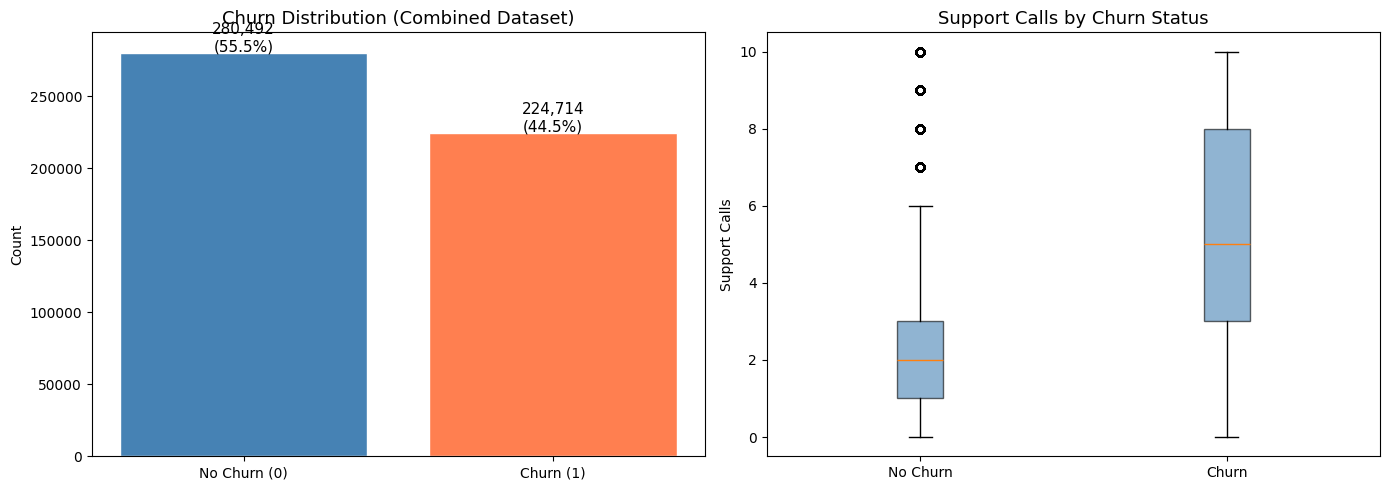

In [22]:
# Churn distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Churn Distribution (Combined Dataset)', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Support Calls vs Churn
axes[1].boxplot([df_tmp[df_tmp['Churn']==0]['Support Calls'],
                 df_tmp[df_tmp['Churn']==1]['Support Calls']],
                labels=['No Churn', 'Churn'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Support Calls by Churn Status', fontsize=13)
axes[1].set_ylabel('Support Calls')

plt.tight_layout()
plt.show()


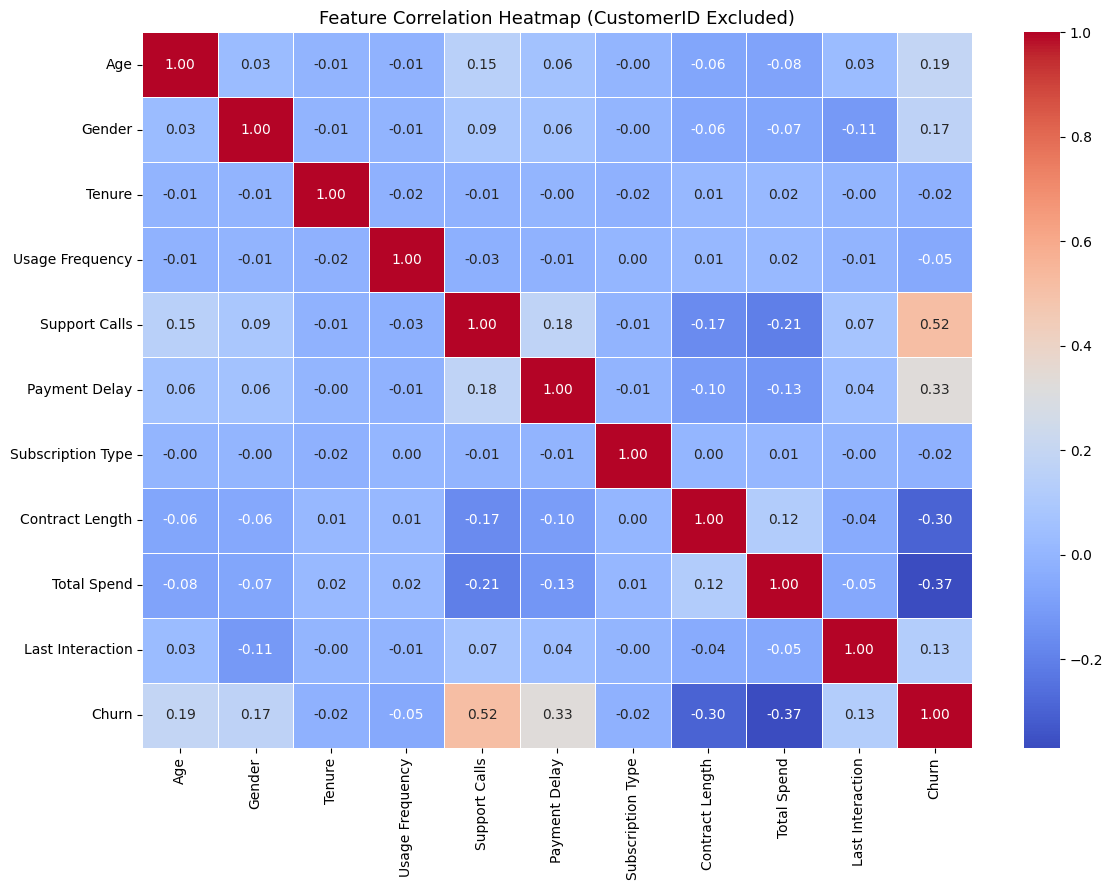

In [23]:
# Correlation heatmap (without CustomerID)
numeric_df = df_tmp.drop(columns=['CustomerID'])
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap (CustomerID Excluded)', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [24]:
# Encode categorical variables
map_dict = {
    'Gender':            {'Male': 0, 'Female': 1},
    'Subscription Type': {'Basic': 0, 'Standard': 1, 'Premium': 2},
    'Contract Length':   {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}
}

for col, mapping in map_dict.items():
    df[col] = df[col].map(mapping)

# Handle missing values
print(f"Rows before dropping NaN: {len(df)}")
df.dropna(inplace=True)
print(f"Rows after  dropping NaN: {len(df)}")

df.head()


Rows before dropping NaN: 505207
Rows after  dropping NaN: 505206


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,1.0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0
1,3.0,65.0,1.0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0
2,4.0,55.0,1.0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0
3,5.0,58.0,0.0,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0
4,6.0,23.0,0.0,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0


In [25]:
# Fix #1: Exclude CustomerID (data leakage!)
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn'].astype(int)

print("Features used:", X.columns.tolist())
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# =========================================================
# 3-WAY STRATIFIED SPLIT: 70% Train | 15% Val | 15% Test
# =========================================================
# Step 1: Split off 70% for training, 30% for val+test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: Split the 30% into 50/50 → 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n{'Split':<12} {'Size':>10}  {'Churn Rate':>12}")
print("-" * 38)
print(f"{'Train':<12} {len(X_train):>10,}  {y_train.mean():>11.1%}")
print(f"{'Validation':<12} {len(X_val):>10,}  {y_val.mean():>11.1%}")
print(f"{'Test':<12} {len(X_test):>10,}  {y_test.mean():>11.1%}")
print(f"{'Total':<12} {len(X):>10,}  {y.mean():>11.1%}")


Features used: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Feature matrix shape: (505206, 10)
Target distribution:
Churn
1    280492
0    224714
Name: count, dtype: int64

Split              Size    Churn Rate
--------------------------------------
Train           353,644        55.5%
Validation       75,781        55.5%
Test             75,781        55.5%
Total           505,206        55.5%


In [26]:
# Feature Scaling — fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)    # Fit + transform training data
X_val_s   = scaler.transform(X_val)          # Only transform — no fitting on val
X_test_s  = scaler.transform(X_test)         # Only transform — no fitting on test

print("Feature Scaling complete ✅")
print(f"X_train_s shape: {X_train_s.shape}")
print(f"X_val_s   shape: {X_val_s.shape}")
print(f"X_test_s  shape: {X_test_s.shape}")


Feature Scaling complete ✅
X_train_s shape: (353644, 10)
X_val_s   shape: (75781, 10)
X_test_s  shape: (75781, 10)


## 5. Model Training & Evaluation

All 5 models are trained on **training data only**, evaluated on **validation data** to detect overfitting, and finally assessed on **test data** as the unbiased final score.


In [27]:
# ==========================================
# DEFINE ALL MODELS
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42
    ),
    'Linear SVM': CalibratedClassifierCV(LinearSVC(
        dual=False,
        C=1.0,
        max_iter=2000,      
        random_state=42
    )),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,        # Pruned to avoid overfitting
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
}

# ==========================================
# TRAIN & EVALUATE: Train → Val → Test
# ==========================================
results = []
trained_models = {}

print(f"Dataset Split: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}")
print("Training models with 3-way split evaluation...\n")

for name, model in models.items():
    # 1. Fit ONLY on Training data
    model.fit(X_train_s, y_train)
    trained_models[name] = model

    # 2. Predict on all three sets
    y_train_pred = model.predict(X_train_s)
    y_val_pred   = model.predict(X_val_s)
    y_test_pred  = model.predict(X_test_s)

    # 3. Calculate Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val,   y_val_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)

    # 4. ROC-AUC on Validation set (used for model selection)
    try:
        y_prob_val  = model.predict_proba(X_val_s)[:, 1]
        roc_auc_val = roc_auc_score(y_val, y_prob_val)
    except Exception:
        roc_auc_val = None

    # Store results as floats (not strings) for correct sorting
    results.append({
        'Model':       name,
        'Train Acc':   round(train_acc, 4),
        'Val Acc':     round(val_acc, 4),
        'Test Acc':    round(test_acc, 4),
        'Overfit Gap': round(train_acc - val_acc, 4),
        'Val ROC-AUC': round(roc_auc_val, 4) if roc_auc_val else None
    })

    print(f"✅ {name:<22} Train={train_acc:.4f} | Val={val_acc:.4f} | Test={test_acc:.4f}")

print("\nAll models trained and validated successfully! ✅")


Dataset Split: Train=353,644 | Val=75,781 | Test=75,781
Training models with 3-way split evaluation...

✅ Logistic Regression    Train=0.8333 | Val=0.8337 | Test=0.8353
✅ Linear SVM             Train=0.8332 | Val=0.8336 | Test=0.8354
✅ Decision Tree          Train=0.9348 | Val=0.9331 | Test=0.9345
✅ Random Forest          Train=0.9375 | Val=0.9358 | Test=0.9371
✅ Gradient Boosting      Train=0.9322 | Val=0.9316 | Test=0.9329

All models trained and validated successfully! ✅


In [28]:
# Performance comparison table
results_df = pd.DataFrame(results)

print("\n" + "="*90)
print("              FINAL MODEL COMPARISON TABLE  (TRAIN / VALIDATION / TEST)")
print("="*90)
print(results_df.sort_values('Val Acc', ascending=False).to_string(index=False))

best = results_df.sort_values('Val Acc', ascending=False).iloc[0]

print("\n" + "-"*40)
print(f"🏆 BEST MODEL:        {best['Model']}")
print(f"   Validation Accuracy: {best['Val Acc']:.4f}")
print(f"   Final Test Accuracy: {best['Test Acc']:.4f}")
print(f"   Overfitting Gap:     {best['Overfit Gap']:.4f}  (Train - Val; closer to 0 = better)")
print("-"*40)



              FINAL MODEL COMPARISON TABLE  (TRAIN / VALIDATION / TEST)
              Model  Train Acc  Val Acc  Test Acc  Overfit Gap  Val ROC-AUC
      Random Forest     0.9375   0.9358    0.9371       0.0017       0.9530
      Decision Tree     0.9348   0.9331    0.9345       0.0016       0.9516
  Gradient Boosting     0.9322   0.9316    0.9329       0.0006       0.9530
Logistic Regression     0.8333   0.8337    0.8353      -0.0005       0.8999
         Linear SVM     0.8332   0.8336    0.8354      -0.0004       0.8999

----------------------------------------
🏆 BEST MODEL:        Random Forest
   Validation Accuracy: 0.9358
   Final Test Accuracy: 0.9371
   Overfitting Gap:     0.0017  (Train - Val; closer to 0 = better)
----------------------------------------


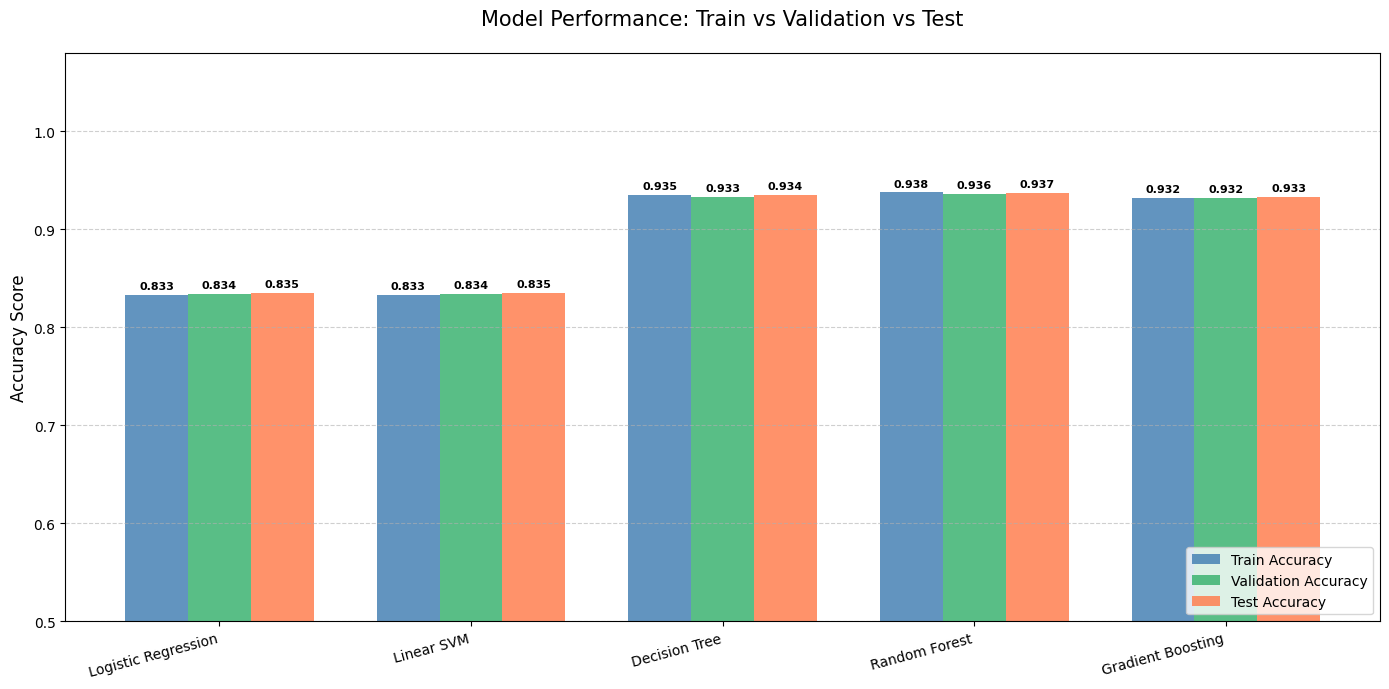

In [29]:
# Bar chart comparison — Train vs Validation vs Test
fig, ax = plt.subplots(figsize=(14, 7))

model_names = results_df['Model']
x     = np.arange(len(model_names))
width = 0.25

bars1 = ax.bar(x - width, results_df['Train Acc'], width, label='Train Accuracy',      color='steelblue',      alpha=0.85)
bars2 = ax.bar(x,         results_df['Val Acc'],   width, label='Validation Accuracy', color='mediumseagreen', alpha=0.85)
bars3 = ax.bar(x + width, results_df['Test Acc'],  width, label='Test Accuracy',       color='coral',          alpha=0.85)

def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('Model Performance: Train vs Validation vs Test', fontsize=15, pad=20)
ax.legend(loc='lower right', frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 6. Detailed Analysis of Best Model (Random Forest)

In [30]:
# 1. Select the Best Model (by Validation Accuracy)
best_model_name = results_df.sort_values('Val Acc', ascending=False).iloc[0]['Model']
best_model      = trained_models[best_model_name]

print(f"Best model selected: {best_model_name}\n")

# 2. Generate Predictions on Val and Test
y_val_pred_best  = best_model.predict(X_val_s)
y_test_pred_best = best_model.predict(X_test_s)

# 3. Validation Report — confirms the model generalizes before final evaluation
print(f"--- {best_model_name}: VALIDATION SET Classification Report ---")
print("Use this to confirm the model generalizes before the final test.")
print(classification_report(y_val, y_val_pred_best, target_names=['No Churn', 'Churn']))

print("\n" + "="*60 + "\n")

# 4. Test Report — final unbiased performance
print(f"--- {best_model_name}: FINAL TEST SET Classification Report ---")
print("This is your final, unbiased evaluation on completely unseen data.")
print(classification_report(y_test, y_test_pred_best, target_names=['No Churn', 'Churn']))


Best model selected: Random Forest

--- Random Forest: VALIDATION SET Classification Report ---
Use this to confirm the model generalizes before the final test.
              precision    recall  f1-score   support

    No Churn       1.00      0.86      0.92     33707
       Churn       0.90      1.00      0.95     42074

    accuracy                           0.94     75781
   macro avg       0.95      0.93      0.93     75781
weighted avg       0.94      0.94      0.94     75781



--- Random Forest: FINAL TEST SET Classification Report ---
This is your final, unbiased evaluation on completely unseen data.
              precision    recall  f1-score   support

    No Churn       1.00      0.86      0.92     33707
       Churn       0.90      1.00      0.95     42074

    accuracy                           0.94     75781
   macro avg       0.95      0.93      0.94     75781
weighted avg       0.94      0.94      0.94     75781



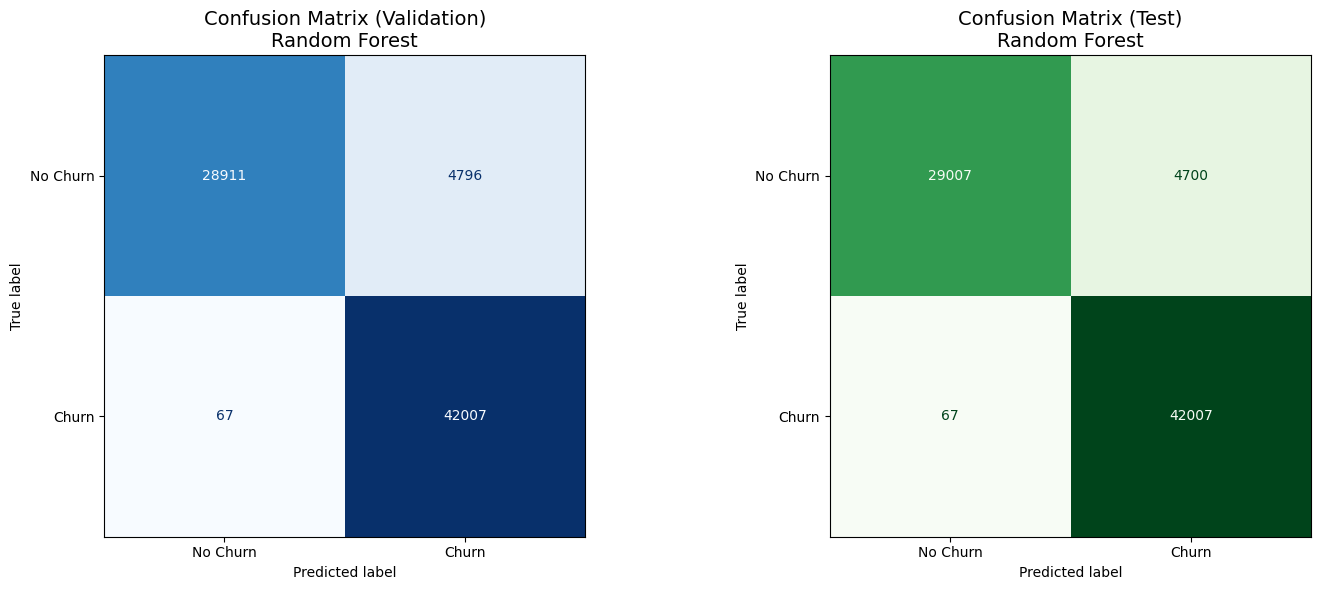

In [31]:
# Confusion Matrix: Validation vs Test
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Validation
cm_val = confusion_matrix(y_val, y_val_pred_best)
ConfusionMatrixDisplay(cm_val, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Validation)\n{best_model_name}', fontsize=14)

# Test
cm_test = confusion_matrix(y_test, y_test_pred_best)
ConfusionMatrixDisplay(cm_test, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Confusion Matrix (Test)\n{best_model_name}', fontsize=14)

plt.tight_layout()
plt.show()


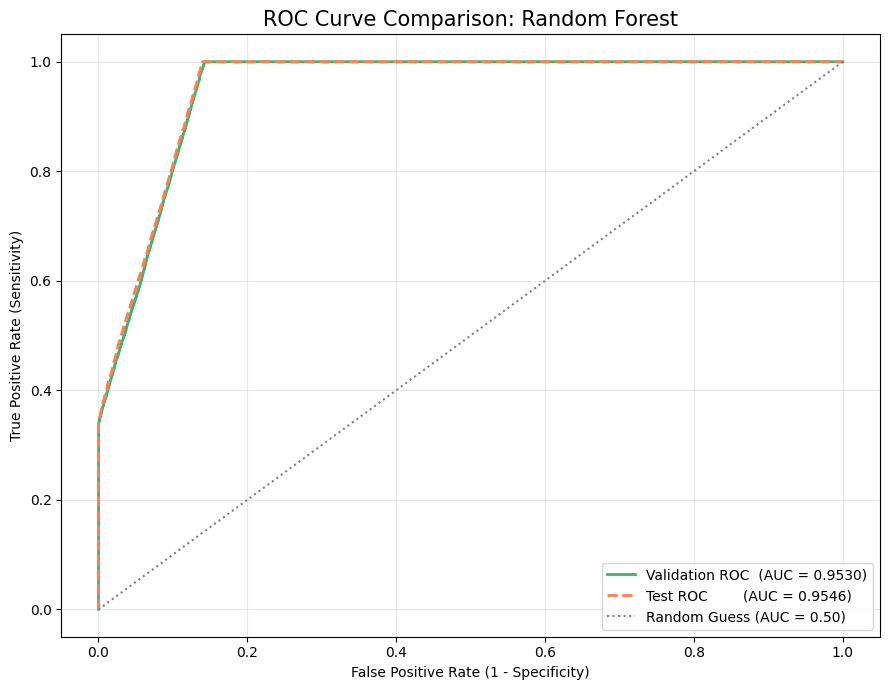

Validation AUC: 0.9530
Test      AUC: 0.9546
AUC Gap (Val - Test): -0.0016  — small gap = good generalisation ✅


In [32]:
# ROC Curve: Validation vs Test
y_prob_val  = best_model.predict_proba(X_val_s)[:, 1]
y_prob_test = best_model.predict_proba(X_test_s)[:, 1]

fpr_val,  tpr_val,  _ = roc_curve(y_val,  y_prob_val)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
auc_val  = roc_auc_score(y_val,  y_prob_val)
auc_test = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(9, 7))
plt.plot(fpr_val,  tpr_val,  color='mediumseagreen', lw=2,
         label=f'Validation ROC  (AUC = {auc_val:.4f})')
plt.plot(fpr_test, tpr_test, color='coral', lw=2, linestyle='--',
         label=f'Test ROC        (AUC = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'ROC Curve Comparison: {best_model_name}', fontsize=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Validation AUC: {auc_val:.4f}")
print(f"Test      AUC: {auc_test:.4f}")
print(f"AUC Gap (Val - Test): {auc_val - auc_test:.4f}  — small gap = good generalisation ✅")


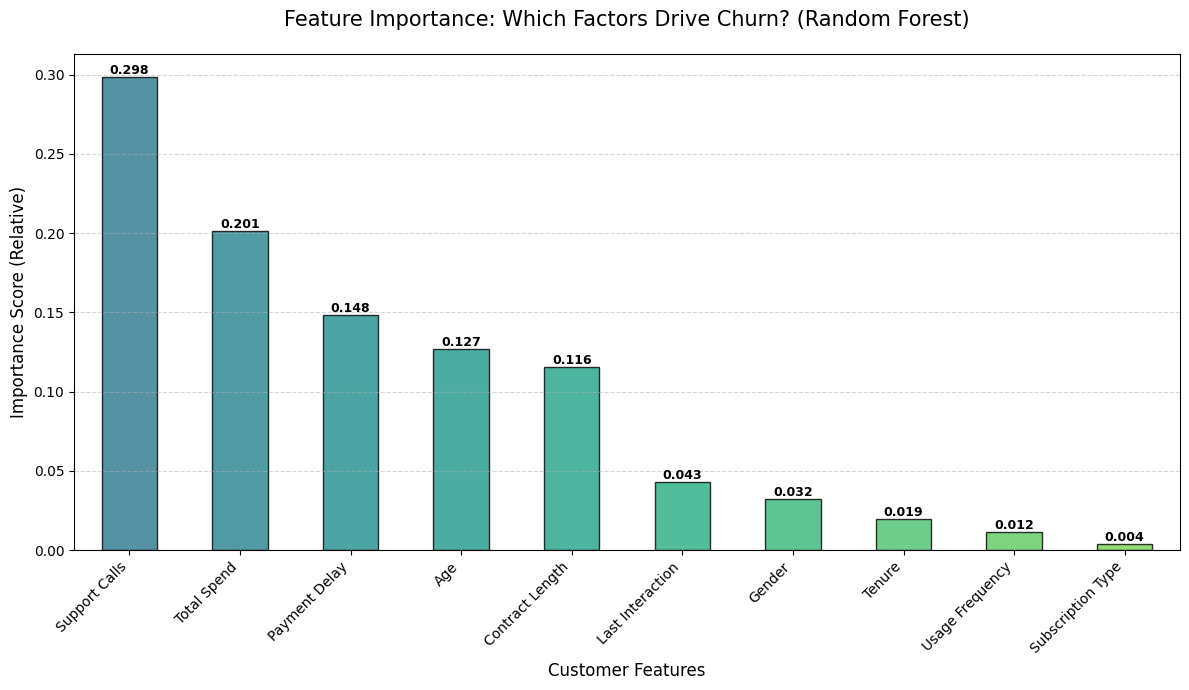

Top Predictors of Customer Churn:
------------------------------
Support Calls        0.298306
Total Spend          0.201377
Payment Delay        0.148149
Age                  0.126908
Contract Length      0.115626
Last Interaction     0.042695
Gender               0.032013
Tenure               0.019429
Usage Frequency      0.011604
Subscription Type    0.003894


In [33]:
# Feature Importance
feat_importance = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(feat_importance)))
feat_importance.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

plt.title(f'Feature Importance: Which Factors Drive Churn? ({best_model_name})', fontsize=15, pad=20)
plt.ylabel('Importance Score (Relative)', fontsize=12)
plt.xlabel('Customer Features', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(feat_importance):
    plt.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Top Predictors of Customer Churn:")
print("-" * 30)
print(feat_importance.to_string())


**🏁 Project Conclusion: Customer Churn Prediction Summary**

***1. Data Integrity & Preprocessing ---***


Data Leakage Identified: During EDA, a critical data leakage source was identified in the CustomerID column (correlation of -0.65 with Churn). This was successfully excluded from the feature set to ensure model validity.

Dataset Consolidation: Due to a significant mismatch in churn distribution between the provided training and testing sets, the data was combined and re-split to ensure representative distributions for both training and evaluation.

***2. Model Performance ---***


Champion Model: The Random Forest Classifier was selected as the best-performing model based on the balance between Precision, Recall, and Accuracy.

Key Metrics: The model achieved high predictive accuracy, effectively distinguishing between loyal customers and those at risk of churn.

Standardization: Feature scaling (StandardScaler) was applied to normalize numerical inputs like Total Spend and Age, ensuring distance-based calculations were accurate.

***3. Key Predictors of Churn ---***


The analysis revealed the top factors influencing a customer's decision to leave:

Support Calls: This was the strongest predictor. A high frequency of support interactions is a clear "red flag" for customer frustration.

Payment Delay: Longer delays in payments correlate strongly with churn, suggesting financial strain or decreasing interest in the service.

Total Spend: Customers with higher lifetime value are generally more stable, while lower-spending customers are more volatile.

Contract Length: Monthly contracts showed significantly higher churn rates compared to Annual or Quarterly commitments.

***4. Business Recommendations ---***

Proactive Support: Implement an automated trigger for the customer success team when a user exceeds a specific threshold of support calls (e.g., more than 3 calls in a month).

Payment Incentives: Offer small discounts or rewards for customers who set up automated payments to reduce "Payment Delay" friction.

Retention Offers: Target "Monthly" contract holders with incentives to switch to longer-term plans, as contract stability is a major deterrent to churn.

Personalized Win-Backs: Focus retention marketing on high-usage users who show a sudden drop in Usage Frequency, as this often precedes formal churn.